# Multiple Integrals

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Numerical Integration - Rectangle Rule


Approximate an integral by taking the sum of the areas of many rectangles. The more rectangles you add the more accurate your sum. For example let's try taking the integral of Approximate the integral by an area of a rectangle:

$$
\int_{0}^1 x^3 \, dx 
$$


In [45]:
#define the function
def f(x):
    return x**3

x = np.linspace(0, 1, 10)
y = f(x)

#so the main idea hear is that our height is y and we want to multiply that by some area dx.
print(x)

[0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ]


Remember that linspace makes an array of equally distant sizes. Using this fact we can write out our element dx.

In [46]:
dx = x[1] - x[0] 
print(dx)

0.1111111111111111


In [47]:
#now we have multiply dx by the height y and sum up all the elements.
#we want to ignore the last element of the array y because that would introduce another rectangle that we don't want to count.
#what we are actually doing is called the left hand riemann sums 

integral = np.sum(y[:-1]) * dx
print("Approximate integral = ", integral)

Approximate integral =  0.19753086419753083


This isn't very accurate because our dx is large. Remember back to calc one when you were calculating reimann sums. It's the same idea. The more rectangles you use, the more accurate your integral becomes. You can go even further using midpoint rectangles or the trapezoidal rule. For now, let's try using a smaller dx

In [48]:
def f(x):
    return x**3

x = np.linspace(0, 1, 100)
y = f(x)
dx = x[1] - x[0] 
print("dx interval", dx)
# Slice [:-1] takes all elements EXCEPT the last one
integral_left = np.sum(y[:-1]) * dx
print("Left Riemann sum =", integral_left)

dx interval 0.010101010101010102
Left Riemann sum = 0.24497500255076018


The approximation is slowly converging to the correct answer of 0.25. The smaller the dx we use, the more accurate our approximation.
Let's visualize what is happening. The code here isn't important. Pay attention the visual produced from the code.

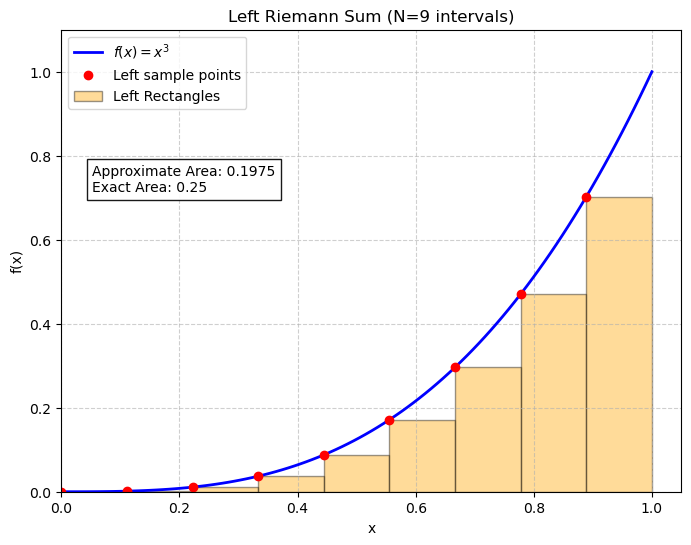

In [50]:
def f(x):
    return x**3

n_points = 10
x_rect = np.linspace(0, 1, n_points)
y_rect = f(x_rect)
dx = x_rect[1] - x_rect[0]

# 3. Setup a denser array for a smooth continuous curve
x_curve = np.linspace(0, 1, 100)
y_curve = f(x_curve)

# 4. Create the plot
plt.figure(figsize=(8, 6))

# Plot the continuous function
plt.plot(x_curve, y_curve, 'b-', label='$f(x) = x^3$', linewidth=2)

# Plot the Left Rectangles
# We use [:-1] to select the left edges and heights, dropping the last point at x=1
plt.bar(x_rect[:-1], y_rect[:-1], width=dx, align='edge', alpha=0.4, 
        color='orange', edgecolor='black', label='Left Rectangles')

# Plot the sample points on the curve (left edges only)
plt.plot(x_rect[:-1], y_rect[:-1], 'ro', label='Left sample points')

# Formatting the plot
plt.title(f'Left Riemann Sum (N={n_points-1} intervals)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.xlim(0, 1.05) 
plt.ylim(0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Calculate and print the approximate area for reference
integral_left = np.sum(y_rect[:-1]) * dx
plt.text(0.05, 0.65, f"Approximate Area: {integral_left:.4f}\nExact Area: 0.25", 
         transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.9))

plt.show()

You see if we didn't exlcude that last rectangle our approximation would be worse. 

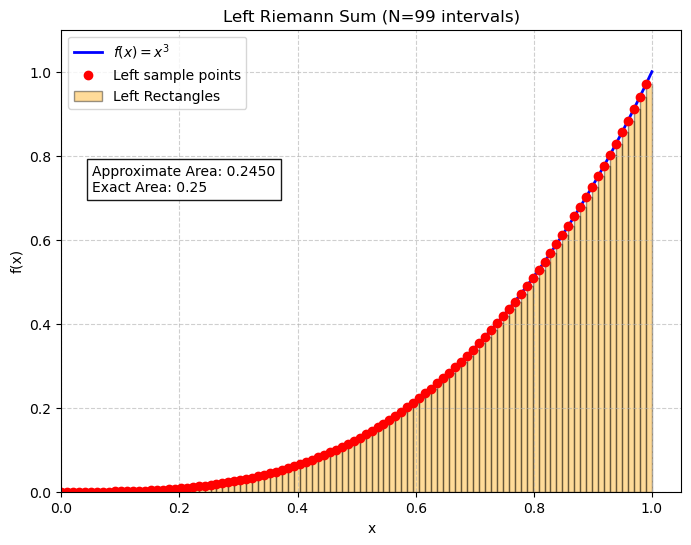

In [58]:
def f(x):
    return x**3

n_points = 100
x_rect = np.linspace(0, 1, n_points)
y_rect = f(x_rect)
dx = x_rect[1] - x_rect[0]

# 3. Setup a denser array for a smooth continuous curve
x_curve = np.linspace(0, 1, 100)
y_curve = f(x_curve)

# 4. Create the plot
plt.figure(figsize=(8, 6))

# Plot the continuous function
plt.plot(x_curve, y_curve, 'b-', label='$f(x) = x^3$', linewidth=2)

# Plot the Left Rectangles
# We use [:-1] to select the left edges and heights, dropping the last point at x=1
plt.bar(x_rect[:-1], y_rect[:-1], width=dx, align='edge', alpha=0.4, 
        color='orange', edgecolor='black', label='Left Rectangles')

# Plot the sample points on the curve (left edges only)
plt.plot(x_rect[:-1], y_rect[:-1], 'ro', label='Left sample points')

# Formatting the plot
plt.title(f'Left Riemann Sum (N={n_points-1} intervals)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.xlim(0, 1.05) 
plt.ylim(0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Calculate and print the approximate area for reference
integral_left = np.sum(y_rect[:-1]) * dx
plt.text(0.05, 0.65, f"Approximate Area: {integral_left:.4f}\nExact Area: 0.25", 
         transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.9))

plt.show()

## Problem 1: 
Let's try solving this problem: 
$$
\int_{0}^2 e^{-x^2} \, dx 
$$
The real power behind these approximations is being able to solve integrals that are difficult or otherwise impossible to solve by hand.

In [70]:
#as always define your function
def f(x):
    return np.e**(-x**2)

x = np.linspace(0, 2, 10000)
y = f(x)
dx = x[1] - x[0] 
print("dx interval", dx)
# Slice [:-1] takes all elements EXCEPT the last one
integral_left = np.sum(y[:-1]) * dx
print("Left Riemann sum =", integral_left)

dx interval 0.00020002000200020003
Left Riemann sum = 0.8821795687721009


This is the same idea we will use for multiple integrals. Instead of rectangles that we add up, we will add up a many rectangular prisms.

## Numerical Double Integrals
Suppose that we want to compute: $$
\iint_R f(x, y) \,dx\,dy
$$
Over the region 0 < x <2, and 0 < y < 1. With $$f(x,y) = x^2 + y^2$$ 

In [4]:
def f(x, y):
    return x**2 + y**2

x = np.linspace(0, 2, 100)
y = np.linspace(0, 1, 100)

X, Y = np.meshgrid(x, y)

Z = f(X, Y)

So the area element here dA = dxdy

In [8]:
dx = x[1] - x[0]
dy = y[1] - y[0]

da = dx * dy
integral = np.sum(Z[:-1, :-1]) * da

print("Approximate integral = ", integral)

Approximate integral =  3.282998333503385


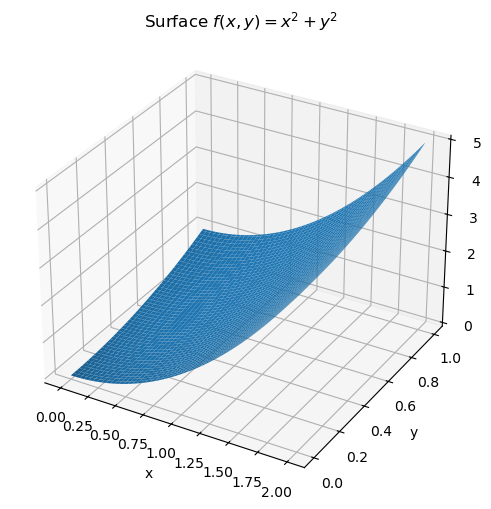

In [9]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

ax.plot_surface(X, Y, Z)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x,y)")
ax.set_title(r"Surface $f(x,y)=x^2+y^2$")

plt.show()

## Problem 2: Mass of nonuniform lamina

A lamina has surface mass density $$\rho(x,y) = 1 + x + y $$
The mass is $$
M = \iint_R \rho(x, y) \,dA
$$
With the region being 0<x<2 and 0<y<1

In [14]:
def rho(x, y):
    return 1 + x + y

rho_values = rho(X, Y)

M = np.sum(rho_values[:-1, :-1]) * da

print("Mass =", M)

Mass = 4.969696969696971


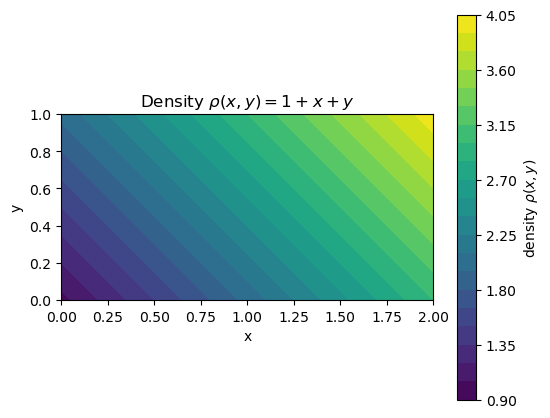

In [15]:
plt.figure(figsize=(6, 5))

plt.contourf(X, Y, rho_values, levels=20)
plt.colorbar(label=r"density $\rho(x,y)$")

plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Density $\rho(x,y)=1+x+y$")
plt.gca().set_aspect("equal")

plt.show()

## Integration over a circular region
Let's say we want to integrate over a disk of radius R = 1:
$$x^2 + y^2 <1 $$
with density 
$$
\rho(x,y) = 1 + x^2 + y^2
$$

In [21]:
R = 1.0

x = np.linspace(-R, R, 300)
y = np.linspace(-R, R, 300)

X, Y = np.meshgrid(x, y)

dx = x[1] - x[0]
dy = y[1] - y[0]
dA = dx * dy

In [22]:
inside = X**2 + Y**2 <= R**2

In [23]:
rho_disk = 1 + X**2 + Y**2

In [28]:
rho_eval = rho_disk[:-1, :-1]
mask_eval = inside[:-1, :-1]

M_disk = np.sum(rho_eval[mask_eval]) * dA

print("Mass of disk =", M_disk)

Mass of disk = 4.708149811333015


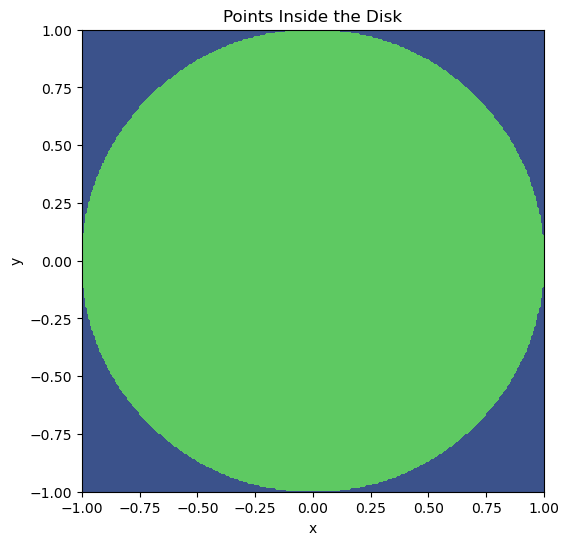

In [29]:
plt.figure(figsize=(6, 6))

plt.contourf(X, Y, inside, levels=1)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Points Inside the Disk")
plt.gca().set_aspect("equal")

plt.show()